<a href="https://colab.research.google.com/github/LuciaKajanova/dspracticum25_flowers_team/blob/main/HW3_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Data preparation


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from fastai.vision.all import *
from pathlib import Path

root = Path('/content/drive/MyDrive/data/flowers_dataset')
train_root = root/'train'
test_root  = root/'test'

assert train_root.exists() and test_root.exists()

dls = ImageDataLoaders.from_folder(
    train_root,
    valid_pct=0.2, seed=42,          # validation split from TRAIN
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224, min_scale=0.75),
    bs=64
)

print("Classes:", dls.vocab)

Classes: ['daffodil', 'daisy', 'rose', 'sunflower', 'tulip']


In [8]:
import warnings

# to ignore the palette warnings
warnings.filterwarnings(
    "ignore",
    message="Palette images with Transparency expressed in bytes should be converted to RGBA images",
    category=UserWarning
)

# Train the model

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.to_fp16()  # optional speed-up on GPU

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


SuggestedLRs(valley=0.0014454397605732083)
Using LR: 1.45e-03


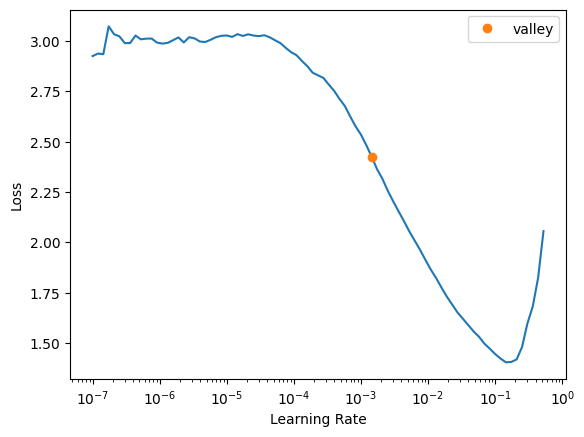

In [10]:
sug = learn.lr_find()      # Suggestions object (new fastai)
print(sug)                 # shows .valley and .steep
lr = float(getattr(sug, 'valley', 3e-3))  # safe fallback
print(f"Using LR: {lr:.2e}")


In [12]:
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback

cbs = [
    SaveModelCallback(monitor='valid_loss', fname='model_cleansplit'),
    EarlyStoppingCallback(monitor='valid_loss', patience=3)
]

epochs = 10
learn.fine_tune(epochs, base_lr=lr, cbs=cbs)


epoch,train_loss,valid_loss,error_rate,time
0,2.322723,0.815072,0.308824,00:55


Better model found at epoch 0 with valid_loss value: 0.8150716423988342.


epoch,train_loss,valid_loss,error_rate,time
0,0.905346,0.530453,0.227941,00:42
1,0.797156,0.302467,0.139706,00:42
2,0.623202,0.204739,0.066176,00:41
3,0.488923,0.190135,0.066176,00:40
4,0.398807,0.153960,0.058824,00:41
5,0.334689,0.135334,0.044118,00:41
6,0.273189,0.133152,0.044118,00:42
7,0.233229,0.125447,0.044118,00:42
8,0.200692,0.125727,0.044118,00:42
9,0.174291,0.124725,0.044118,00:40


Better model found at epoch 0 with valid_loss value: 0.5304532647132874.
Better model found at epoch 1 with valid_loss value: 0.30246731638908386.
Better model found at epoch 2 with valid_loss value: 0.20473863184452057.
Better model found at epoch 3 with valid_loss value: 0.1901354044675827.
Better model found at epoch 4 with valid_loss value: 0.15396000444889069.
Better model found at epoch 5 with valid_loss value: 0.13533420860767365.
Better model found at epoch 6 with valid_loss value: 0.13315215706825256.
Better model found at epoch 7 with valid_loss value: 0.12544679641723633.
Better model found at epoch 9 with valid_loss value: 0.12472525984048843.


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


VALID accuracy: 0.956 | error_rate: 0.044


daffodil: 0.926
daisy: 1.000
rose: 0.929
sunflower: 0.971
tulip: 0.963
              precision    recall  f1-score   support

    daffodil       0.93      0.93      0.93        27
       daisy       1.00      1.00      1.00        19
        rose       0.90      0.93      0.91        28
   sunflower       1.00      0.97      0.99        35
       tulip       0.96      0.96      0.96        27

    accuracy                           0.96       136
   macro avg       0.96      0.96      0.96       136
weighted avg       0.96      0.96      0.96       136



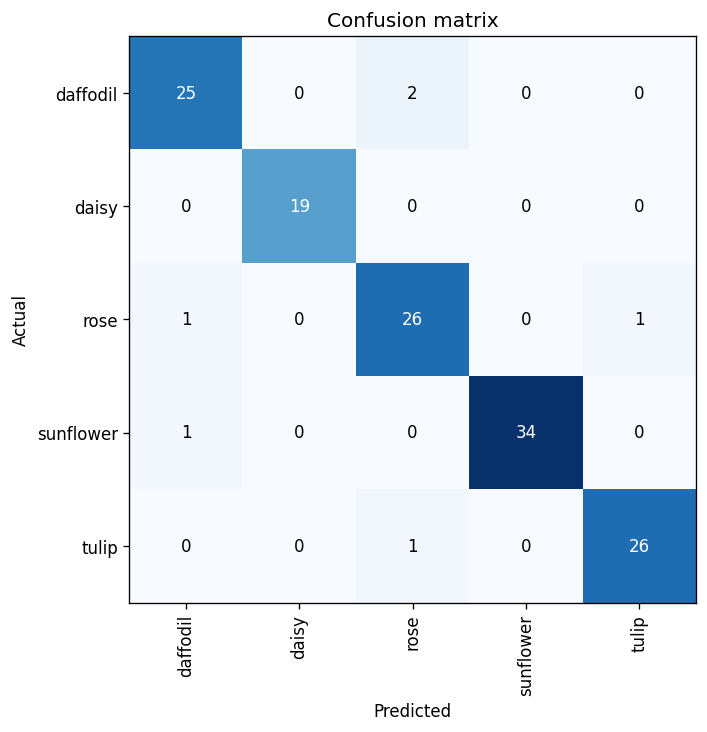

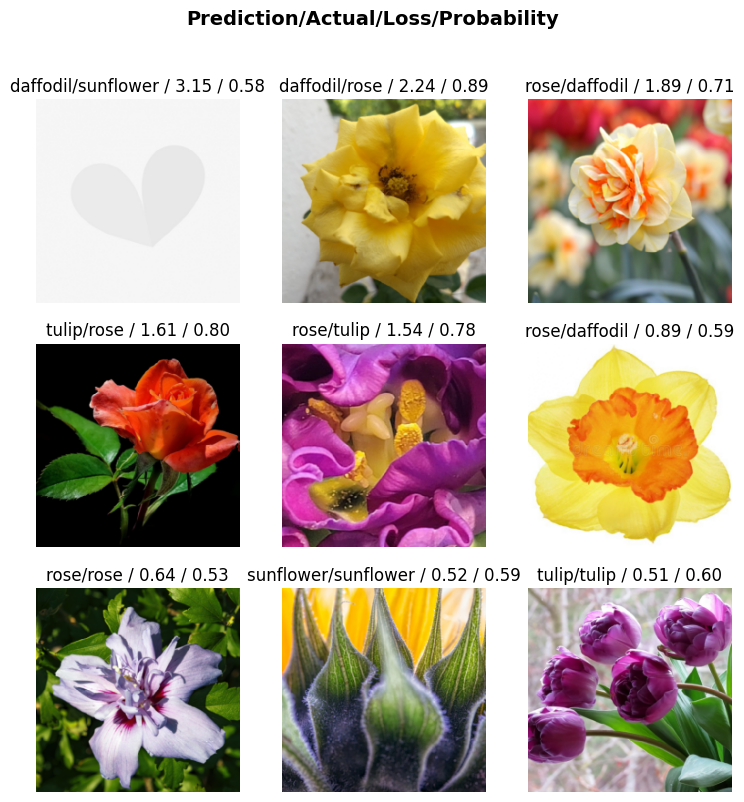

In [13]:
# Load best weights from phase 1
learn.load('model_cleansplit')

from fastai.vision.all import *
from sklearn.metrics import classification_report

# Confusion matrix + hardest mistakes
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(6,6), dpi=120)
interp.plot_top_losses(9, nrows=3, figsize=(9,9))

# Accuracy / error_rate on VALID
preds, targs = learn.get_preds(dl=dls.valid)
err = error_rate(preds, targs).item()
acc = 1 - err
print(f"VALID accuracy: {acc:.3f} | error_rate: {err:.3f}")

# Per-class accuracy
cm = interp.confusion_matrix()
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for cls, a in zip(dls.vocab, per_class_acc):
    print(f"{cls}: {a:.3f}")

# Detailed precision/recall/F1
print(classification_report(targs.numpy(),
                            preds.argmax(dim=1).numpy(),
                            target_names=dls.vocab))


### Label smoothing

In [16]:
# Start from the phase-1 best checkpoint
learn.load('model_cleansplit')

# Use Label Smoothing for a bit more generalization
learn.loss_func = LabelSmoothingCrossEntropy()

from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback
cbs_ls = [
    SaveModelCallback(monitor='valid_loss', fname='model_cleansplit_ls'),
    EarlyStoppingCallback(monitor='valid_loss', patience=2)
]

# Smaller LR than before
extra_lr = max(1e-4, float(lr)/3)
learn.fine_tune(3, base_lr=extra_lr, cbs=cbs_ls)


epoch,train_loss,valid_loss,error_rate,time
0,0.865445,0.782300,0.044118,00:43


Better model found at epoch 0 with valid_loss value: 0.7822995781898499.


epoch,train_loss,valid_loss,error_rate,time
0,0.787159,0.704236,0.036765,00:44
1,0.759833,0.633417,0.036765,00:43
2,0.735329,0.628244,0.051471,00:43


Better model found at epoch 0 with valid_loss value: 0.7042360901832581.
Better model found at epoch 1 with valid_loss value: 0.6334166526794434.
Better model found at epoch 2 with valid_loss value: 0.6282439231872559.


/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


VALID (LS) accuracy: 0.949 | error_rate: 0.051


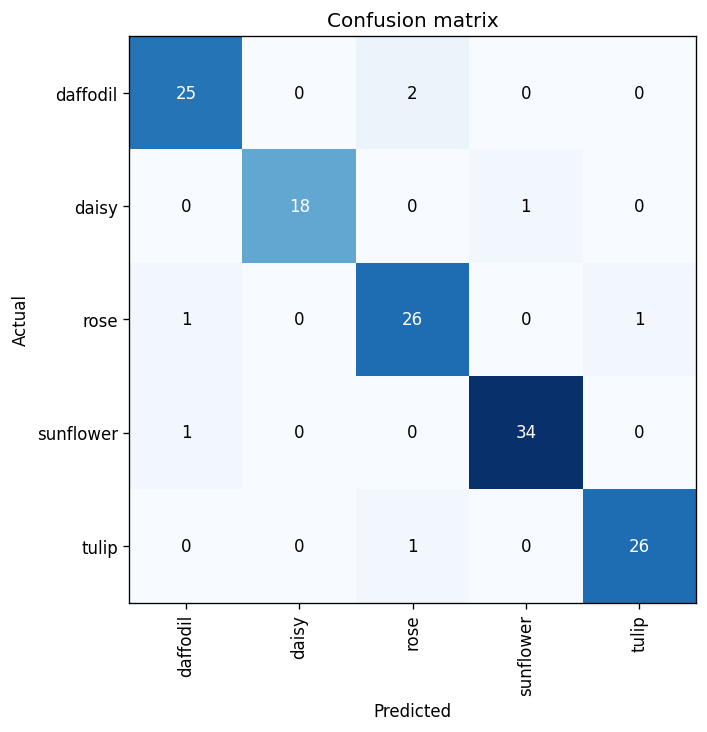

In [17]:
learn.load('model_cleansplit_ls')

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(6,6), dpi=120)

preds, targs = learn.get_preds(dl=dls.valid)
err = error_rate(preds, targs).item()
print(f"VALID (LS) accuracy: {(1-err):.3f} | error_rate: {err:.3f}")


# Test model (without label smoothing)

In [19]:
# 1) Load best checkpoint and build test DataLoader
from pathlib import Path

learn.load('model_cleansplit')

test_path = Path('/content/drive/MyDrive/data/flowers_dataset/test')
test_dl = learn.dls.test_dl(get_image_files(test_path))
len(test_dl.items)

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


242

In [20]:
# 2) Predictions + basic accuracy / error rate
import numpy as np

preds = learn.get_preds(dl=test_dl)[0]   # unlabeled test_dl -> returns only preds
pred_idx = preds.argmax(dim=1)

class_names = learn.dls.vocab
pred_class_names = [class_names[i] for i in pred_idx]
true_class_names = [Path(p).parent.name for p in test_dl.items]

acc = np.mean([t == p for t, p in zip(true_class_names, pred_class_names)])
print(f"Test accuracy: {acc:.3f} | Test error rate: {1-acc:.3f}")


Test accuracy: 0.930 | Test error rate: 0.070


In [23]:
from statistics import mean

print("Test error rate:")
print(1 - mean([actual == predicted for actual, predicted in zip(true_class_names, pred_class_names)]))

Test error rate:
0.07024793388429751


# Export the model

In [28]:
learn.load('model_cleansplit')

from pathlib import Path
export_path = Path('/content/model_cleansplit.pkl')
learn.export(export_path)

from google.colab import files
files.download(str(export_path))



/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>